## 1. Programa BEM en 3D

# 3D Frequency-Domain Boundary Element Method (BEM)

This tutorial demonstrates the implementation of a 3D Boundary Element Method (BEM) to analyze the interaction between regular linear water waves and submerged porous structures.

The formulation is based on:
- Linear potential flow theory
- Time-harmonic (frequency-domain) analysis
- Boundary integral equation formulation

The objective is to compute:
- Wave transmission and reflection

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

from MESH.MAIN_MESH import MAIN_MESH

import meshio

import numpy as np

from ADD_FUNCTIONS.PROCESS_MESH import PROCESS_MESH
from ADD_FUNCTIONS.COORDINATES import COORDINATES
from ADD_FUNCTIONS.ELEMENT_CONNECTION import ELEMENT_CONNECTION
from ADD_FUNCTIONS.COS_DIR import COS_DIR
from ADD_FUNCTIONS.MATCHING import MATCHING

from MATRICES.FUNDA6 import FUNDA6
from MATRICES.FUNDA6_TRI import FUNDA6_TRI
from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.TRILOC6 import TRILOC6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD import BC_FAR_FIELD
from BOUNDARY_CONDITIONS.BC_COMPLEX_G import BC_COMPLEX_G
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from ADD_FUNCTIONS.FX_FUNCTION import FX_FUNCTION
from ADD_FUNCTIONS.ENERGY_FLUX import ENERGY_FLUX
from ADD_FUNCTIONS.NODES_FS import NODES_FS

from ADD_FUNCTIONS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

In [2]:
# Variables of interest

# Water depth
DEPTH = 2.5

# Half wave flume width
WIDTH_CHANNEL = 10

# Cylinder dimensions
RADIO  = 1*DEPTH
HEIGHT = 4/5*DEPTH

#     Point 1      2             3               4
#     ↓            ↓             ↓               ↓
#     +------------+-------------+---------------+
#     |            |   Object    |               |
#     |  Incident  |   .......   |  Transmitted  |   y
#     |     →      |   .     .   |               |   ↑
#(0,0)+.....→......|......+......|...............|    → x
#     |     →      |   .     .   |               |
#     |            |   .......   |               |
#     |            |             |               |
#     +------------+-------------+---------------+

# Point 1, 2, 3 and 4
FLUME_LENGTH_X = [0, 3*DEPTH, 5*DEPTH, 8*DEPTH]

# Location of the center's structures in x and y coordinates
# The middle of the wave flume is at y=0 
LOC_STRUCT_X = [4*DEPTH]
LOC_STRUCT_Y = [0]

# Number of structures
N_struct  = len(LOC_STRUCT_X);

# Number of regions: outer and inner regions
NUM_OF_REG = 1

gravity = 9.8056
rho     = 999.1033

In [3]:
# NUMBER OF FREQUENCIES
ttmax = 1

# WAVE PERIODS
kh = np.linspace(1.00, 1.00, ttmax)
# WAVE HEIGHT
HL = 0.01

In [4]:
# GMSH meshes
MAIN_MESH(DEPTH,WIDTH_CHANNEL,RADIO,HEIGHT,FLUME_LENGTH_X,LOC_STRUCT_X,LOC_STRUCT_Y)

In [5]:
# Process the outer region
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("OUTER_REGION.msh")

In [6]:
# Number of nodes per quad element
NCONEC = 9;

In [7]:
# PRE-ASSIGN
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
N[0] ,  NE[0] ,  KCONEC0 = COORDINATES(MESH_0_POS , MESH_0_QUADS9)

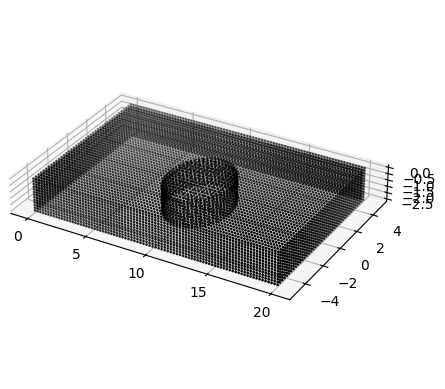

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=1
)

#ax.grid(True)
ax.set_box_aspect([7.5,5,1])  # axis equal

plt.show()

In [10]:
# ELEMENT CONNECTION
REF_R0 , NORMAL0 = ELEMENT_CONNECTION(NCONEC , KCONEC0 , MESH_0_POS , NE[0])

In [11]:
N_total = N[0]

In [12]:
KCON_N_0  = KCONEC0[0:9, :]

KCONEC = KCON_N_0

In [13]:
# FORM SYSTEM OF EQUATIONS FOR EACH REGION
import time

tic = time.perf_counter()
H , G = GHMAT6(MESH_0_POS , NCONEC , KCONEC0 , NE[0] , N[0] , DEPTH);
toc = time.perf_counter()
print("Elapsed time:", toc - tic, "seconds")

Elapsed time: 687.7322603000066 seconds


In [14]:
# FREQUENCY ITERATIONS

# Preallocate if not already done
X_axis = np.zeros(ttmax)

CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)

WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# ============================
# MAIN LOOP
# ============================

for tt in range(ttmax):

    print(tt + 1)

    X_axis[tt] = kh[tt]

    # WAVE NUMBER
    k = kh[tt] / DEPTH

    # WAVE PERIOD
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # WAVE FREQUENCY
    f = 1.0 / T

    # ANGULAR FREQUENCY
    omega = 2*np.pi*f

    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # SAVE MATRICES
    A = H.copy()
    B = G.copy()

    # ------------------------
    # BOUNDARY CONDITIONS
    # ------------------------
    # FREE SURFACE BC
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)

    # FAR FIELD BC
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R0["IN"],  KCONEC, NE, 0)
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R0["OUT"], KCONEC, NE, 0)

    # SCATTERING BC (from incident velocity potential in the left far field)
    BC_S = BC_SCATTERING(Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # RHS VECTOR
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # SOLVE SYSTEM
    Coef_S = np.linalg.solve(A, FX_S)

    # ENERGY FLUX    
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R0["OUT"], MESH_0_POS,
        KCONEC,
        N, NE, 0, 0)

    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI

# END LOOPS

1


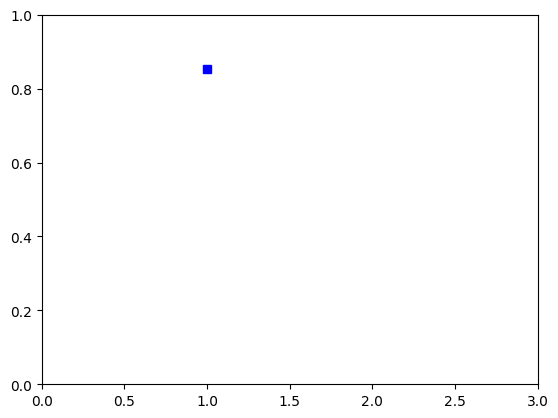

In [15]:
# figure(15)
plt.figure(15)

# plot(kh, KT, 'bs')
# 'bs' stands for blue squares
plt.plot(kh, KT, 'bs')

# xlim([0 1.5])
plt.xlim([0, 3.00])

# ylim([0 1])
plt.ylim([0, 1.0])

# Optional: display the plot
plt.show()

In [16]:
KT
# CORRECT
# lc = 0.75  - array([0.85471201])
# lc = 0.625 - array([0.85467132])
# lc = 0.50  - array([0.85294357])

array([0.85294357])

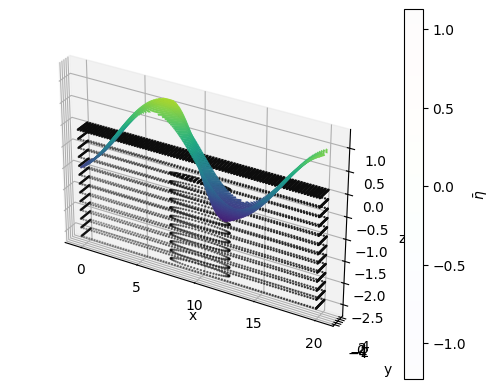

In [17]:
# VISUALIZE FREE SURFACE
PHI_R = VISUAL_FREE_SURFACE(Coef_S, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R0["FS"], MESH_0_POS, MESH_0_POS, KCONEC, N, NE, 0)